# Smart Apartment Data Mining System

This project analyzes apartment rental listings using unsupervised learning techniques.
The goal is to discover hidden patterns in housing data and help users understand apartment groups, unusual listings, and suitable recommendations.

Main techniques used:
1. Clustering using K-Means
2. Dimensionality Reduction using PCA
3. Association Rule Mining using Apriori
4. Anomaly Detection using Isolation Forest
5. Simple recommendation based on user preferences

## **Install Required Libraries**



In [126]:
!pip install pandas numpy matplotlib scikit-learn mlxtend plotly

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings("ignore")

## **Upload Dataset**

In [128]:
from google.colab import files
uploaded = files.upload()

Saving apartments_for_rent_classified_10K.csv to apartments_for_rent_classified_10K (2).csv


# **Read Dataset**

In [129]:
import pandas as pd

file_name = list(uploaded.keys())[0]

df = pd.read_csv(
    file_name,
    encoding="latin1",
    sep=";",
    on_bad_lines="skip"
)

df.head(30)

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401
5,5667891676,housing/rent/apartment,0 BR in New York NY 10019,**RARE GEM WITH PRIVATE OUTDOOR TERRACE****AVA...,"Dishwasher,Elevator,Patio/Deck,Pool,Storage",1.0,0.0,USD,No,Thumbnail,...,"$2,475",Monthly,130,350 West 50th St,Manhattan,NY,40.7629,-73.9885,Listanza,1577289784
6,5668627426,housing/rent/apartment,Studio apartment 2432 Penmar Ave,"This unit is located at 2432 Penmar Ave, Venic...",NaN,NaN,0.0,USD,No,Thumbnail,...,"$1,800",Monthly,132,2432 Penmar Avenue,Venice,CA,33.9932,-118.4609,RentLingo,1577359461
7,5668626687,housing/rent/apartment,"Studio apartment Oak St NW, 16th St NW, Washin...","This unit is located at Oak St NW, 16th St NW,...",NaN,NaN,0.0,USD,No,Thumbnail,...,$840,Monthly,136,NaN,Washington,DC,38.9328,-77.0297,RentLingo,1577359393
8,5668610290,housing/rent/apartment,Studio apartment 333 Hyde St,"This unit is located at 333 Hyde St, San Franc...",Refrigerator,1.0,0.0,USD,No,Thumbnail,...,"$1,495",Monthly,138,333 Hyde St,San Francisco,CA,37.7599,-122.4379,RentLingo,1577358313
9,5668627023,housing/rent/apartment,"Studio apartment A St SE, 19th St SE, Washington","This unit is located at A St SE, 19th St SE, W...",NaN,NaN,0.0,USD,No,Thumbnail,...,$890,Monthly,141,NaN,Washington,DC,38.9118,-77.0132,RentLingo,1577359424


## Basic Dataset Understanding

In this step, we check the dataset size, columns, and basic information.
This helps us understand what features are available before preprocessing.

In [130]:
df.shape

(10000, 22)

In [131]:
df.columns

Index(['id', 'category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time'],
      dtype='object')

In [132]:
for col in data.columns:
    print(f"=== {col} ===")
    print(data[col].nunique(), "unique values")
    print(data[col].unique()[:5])
    print()

=== amenities ===
2248 unique values
['Unknown' 'Dishwasher,Elevator,Patio/Deck,Pool,Storage' 'Refrigerator'
 'AC,Basketball,Cable or Satellite,Gym,Internet Access,Patio/Deck,Pool,Refrigerator'
 'Pool']

=== bathrooms ===
12 unique values
[1.  1.5 2.  2.5 3. ]

=== bedrooms ===
10 unique values
[0. 1. 2. 3. 4.]

=== has_photo ===
3 unique values
['Thumbnail' 'Yes' 'No']

=== pets_allowed ===
4 unique values
['Unknown' 'Cats,Dogs' 'Cats' 'Dogs']

=== price ===
1715 unique values
[1390  925 2475 1495 1695]

=== square_feet ===
1713 unique values
[107 116 130 138 190]

=== cityname ===
1572 unique values
['Arlington' 'Seattle' 'Manhattan' 'San Francisco' 'New Bern']

=== state ===
52 unique values
['VA' 'WA' 'NY' 'CA' 'NC']

=== latitude ===
2384 unique values
[38.891  47.616  40.7629 37.7599 35.0847]

=== longitude ===
2382 unique values
[ -77.0816 -122.3275  -73.9885 -122.4379  -77.0609]

=== square_meters ===
1713 unique values
[ 9.940621 10.776748 12.07739  12.820614 17.65157 ]

=== p

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   5837 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-null   object 
 18  latitud

In [134]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,10000.0,NaN,NaN,NaN,5623395652.8752,70210252.044846,5508654087.0,5509248467.0,5668609592.5,5668626447.25,5668662559.0
category,10000,3,housing/rent/apartment,9996,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,10000,9350,Apartment in great location,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body,10000,9961,"When searching for a pet-friendly One-, Two- a...",6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amenities,6451,2254,Parking,229,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bathrooms,9966.0,NaN,NaN,NaN,1.380544,0.61541,1.0,1.0,1.0,2.0,8.5
bedrooms,9993.0,NaN,NaN,NaN,1.744021,0.942354,0.0,1.0,2.0,2.0,9.0
currency,10000,1,USD,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fee,10000,1,No,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_photo,10000,3,Thumbnail,8907,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Feature Selection

We select only the columns that are useful for our unsupervised analysis.

Selected features:
- price: rent price
- square_feet: apartment size
- bedrooms: number of bedrooms
- bathrooms: number of bathrooms
- amenities: available facilities
- pets_allowed: whether pets are allowed
- has_photo: whether listing has a photo
- cityname and state: location information
- latitude and longitude: geographical location

In [135]:
selected_cols = [
    "amenities",
    "bathrooms",
    "bedrooms",
    "has_photo",
    "pets_allowed",
    "price",
    "square_feet",
    "cityname",
    "state",
    "latitude",
    "longitude"
]

data = df[selected_cols].copy()

data.head()

,amenities,bathrooms,bedrooms,has_photo,pets_allowed,price,square_feet,cityname,state,latitude,longitude
0,NaN,NaN,0.0,Thumbnail,NaN,790,101,Washington,DC,38.9057,-76.9861
1,NaN,NaN,1.0,Thumbnail,NaN,425,106,Evansville,IN,37.9680,-87.6621
2,NaN,1.0,0.0,Thumbnail,NaN,1390,107,Arlington,VA,38.8910,-77.0816
3,NaN,1.0,0.0,Thumbnail,NaN,925,116,Seattle,WA,47.6160,-122.3275
4,NaN,NaN,0.0,Thumbnail,NaN,880,125,Arlington,VA,38.8738,-77.1055


## Missing Values

We check missing values to decide how to clean the dataset.
Critical numerical features such as price, square feet, bedrooms, and bathrooms are needed for clustering.

In [136]:
data.isnull().sum()

,0
amenities,3549
bathrooms,34
bedrooms,7
has_photo,0
pets_allowed,4163
price,0
square_feet,0
cityname,77
state,77
latitude,10


## Data Cleaning

In this step:
1. Convert numerical columns to numeric format.
2. Remove rows with missing important numerical values.
3. Fill missing categorical values with "Unknown".

Only a small number of rows are removed, so the dataset remains large enough for analysis.

In [137]:
numeric_cols = [
    "price",
    "square_feet",
    "bedrooms",
    "bathrooms",
    "latitude",
    "longitude"
]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna(subset=[
    "price",
    "square_feet",
    "bedrooms",
    "bathrooms",
    "latitude",
    "longitude"
])

categorical_cols = [
    "amenities",
    "has_photo",
    "pets_allowed",
    "cityname",
    "state"
]

for col in categorical_cols:
    data[col] = data[col].fillna("Unknown")

data.shape

(9950, 11)

## Convert Square Feet to Square Meters

The original dataset uses square feet.
We convert the apartment size into square meters to improve readability and standardization.

In [138]:
data["square_meters"] = data["square_feet"] * 0.092903

## Removing Extreme Values

Before clustering, we filter out unrealistic apartment listings
that could distort the results.

We apply range filtering to keep only realistic values:

- Price: between 100 and 10,000 per month

- Size: between 100 and 5,000 square feet

This is different from Anomaly Detection (applied later using Isolation Forest),
which detects unusual patterns within the realistic range.

This step ensures the clustering is based on typical market listings.

In [139]:
data["price"].describe()

,price
count,9950.000000
mean,1487.585930
std,1077.350394
min,200.000000
25%,950.000000
50%,1275.000000
75%,1695.000000
max,52500.000000


In [140]:
data["square_meters"].describe()

,square_meters
count,9950.000000
mean,87.632711
std,48.905652
min,9.940621
25%,60.386950
50%,74.601109
75%,102.193300
max,1051.476154


In [141]:
data = data[
    (data["price"] > 100) &
    (data["price"] < 10000) &
    (data["square_feet"] > 100) &
    (data["square_feet"] < 5000)
]

data.shape

(9935, 12)

In [142]:
print(f"Dataset size before cleaning: {df.shape}")
print(f"Dataset size after cleaning:  {data.shape}")
print(f"Rows removed: {df.shape[0] - data.shape[0]}")

Dataset size before cleaning: (10000, 22)
Dataset size after cleaning:  (9935, 12)
Rows removed: 65


## Exploratory Data Analysis

We visualize important features to understand the dataset before applying unsupervised learning.

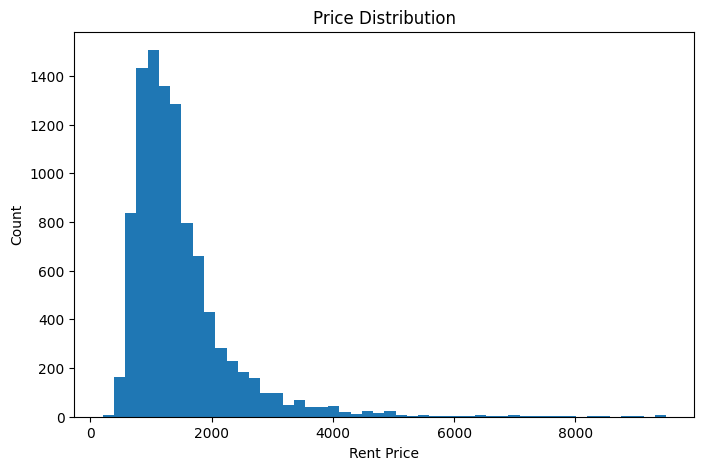

In [143]:
plt.figure(figsize=(8, 5))
plt.hist(data["price"], bins=50)
plt.title("Price Distribution")
plt.xlabel("Rent Price")
plt.ylabel("Count")
plt.show()

### Price Distribution

The price distribution is right-skewed, meaning most apartments
are priced between 500 and 2,000 per month.
A small number of listings have very high prices (above 4,000),
which confirms the importance of the range filtering step we applied earlier.

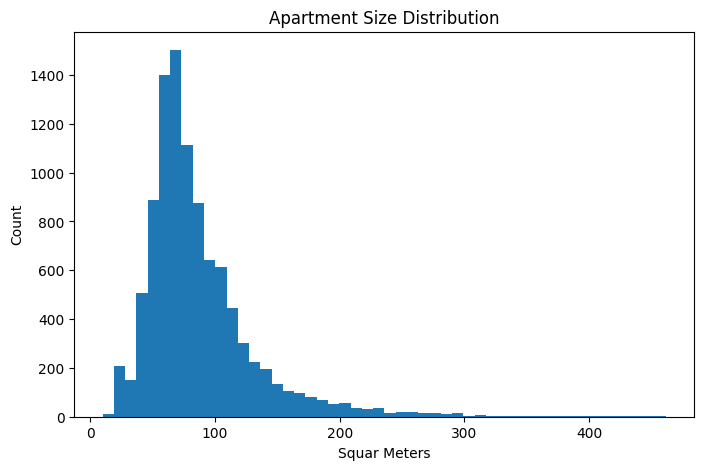

In [144]:
plt.figure(figsize=(8, 5))
plt.hist(data["square_meters"], bins=50)
plt.title("Apartment Size Distribution")
plt.xlabel("Squar Meters")
plt.ylabel("Count")
plt.show()

### Apartment Size Distribution

The size distribution is also right-skewed, with most apartments
ranging between 40 and 150 square meters.
Very large apartments (above 300 m²) are rare,
which is consistent with typical urban rental markets.

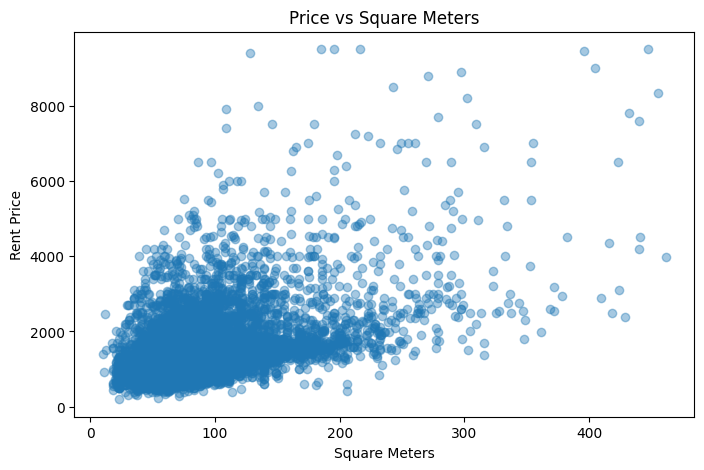

In [145]:
plt.figure(figsize=(8, 5))
plt.scatter(data["square_meters"], data["price"], alpha=0.4)
plt.title("Price vs Square Meters")
plt.xlabel("Square Meters")
plt.ylabel("Rent Price")
plt.show()

### Price vs Size

The scatter plot shows a weak positive relationship between
apartment size and price. While larger apartments tend to cost more,
many small apartments have surprisingly high prices.
This supports our earlier finding that location plays a bigger role
in price than size alone — as seen in Cluster 1, where compact
apartments in California had the highest price per m².

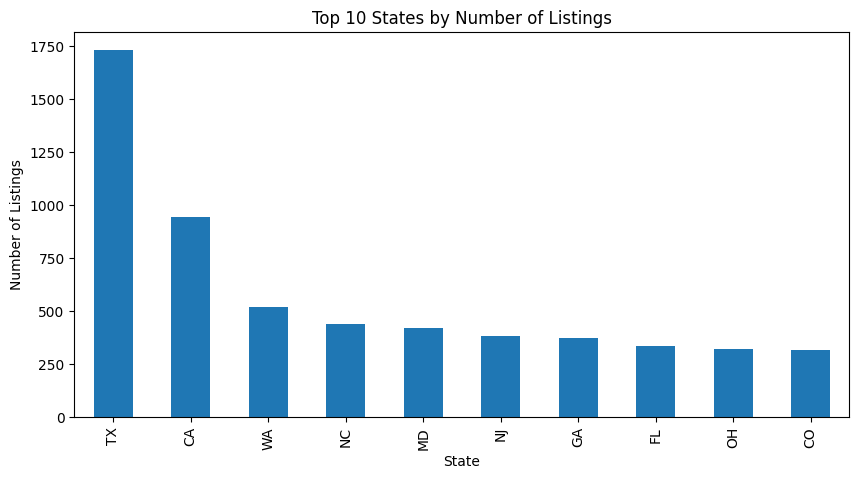

In [146]:

top_states = data["state"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_states.plot(kind="bar")
plt.title("Top 10 States by Number of Listings")
plt.xlabel("State")
plt.ylabel("Number of Listings")
plt.show()

### Top 10 States by Number of Listings

Texas (TX) has the highest number of listings by far, followed by
California (CA) and Washington (WA). This distribution is important
for understanding our clustering results, as states with more listings
naturally have more influence on the cluster patterns.

Notably, California appears second despite having fewer listings than Texas,
yet it dominates Cluster 1 — confirming that CA apartments tend to be
more expensive regardless of quantity.

## Clustering Preparation

We use numerical features for clustering:
- price
- square_meters
- bedrooms
- bathrooms
- latitude
- longitude

We also create a new feature:
- price_per_m2: price divided by square meters,
  which helps distinguish expensive locations from large apartments.

We scale the data using StandardScaler because K-Means
is distance-based, and features with large ranges like price
could dominate the clustering process.

In [147]:
data["price_per_m2"] = data["price"] / data["square_meters"]

cluster_features = [
    "price",
    "square_meters",
    "bedrooms",
    "bathrooms",
    "latitude",
    "longitude",
    "price_per_m2"
]

X = data[cluster_features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-9.30310717e-02, -1.67665278e+00, -1.86547818e+00,
        -6.26131313e-01,  2.16491449e-01,  1.11512825e+00,
         1.13119163e+01],
       [-6.39703105e-01, -1.65848812e+00, -1.86547818e+00,
        -6.26131313e-01,  1.80260618e+00, -1.75699285e+00,
         6.26305559e+00],
       [ 1.18253701e+00, -1.63023197e+00, -1.86547818e+00,
        -6.26131313e-01,  5.56783503e-01,  1.31147218e+00,
         1.73987173e+01],
       [ 3.04110004e-02, -1.61408560e+00, -1.86547818e+00,
        -6.26131313e-01,  1.08691714e-02, -1.76400082e+00,
         9.14068589e+00],
       [ 2.65538757e-01, -1.50913420e+00, -1.86547818e+00,
        -6.26131313e-01,  1.08691714e-02, -1.76400082e+00,
         7.21607560e+00]])

## Scaling the Data

Before applying K-Means, we scale all features using StandardScaler.

StandardScaler transforms each feature by subtracting the mean
and dividing by the standard deviation:

scaled_value = (value - mean) / std

This converts all features to the same scale (z-scores):
- Negative value → below average
- Positive value → above average
- Close to 0     → near average

This step is essential because K-Means is distance-based.
Without scaling, features with large ranges like price ($200 - $10,000)
would dominate over features like bedrooms (1 - 9),
leading to biased clustering results.

## Choosing Number of Clusters

We test different values of K using:
1. Elbow Method
2. Silhouette Score

This helps us choose a suitable number of clusters.

In [148]:
inertias = []
silhouette_scores = []

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

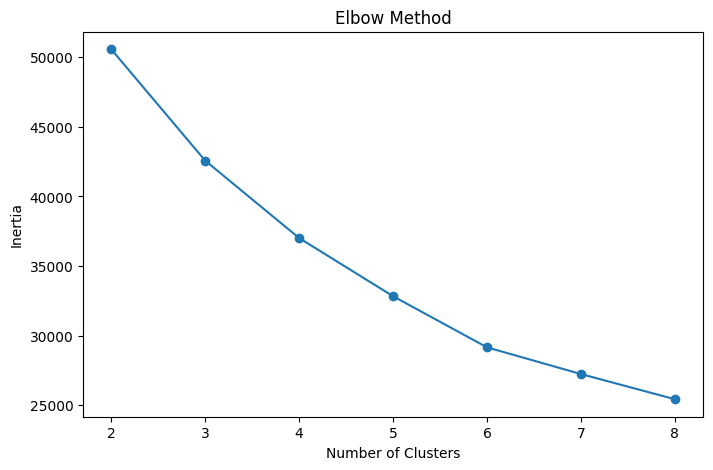

In [149]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

### Elbow Method Results

The inertia decreases as K increases, with a noticeable
change in slope between k=2 and k=4. After k=4, the curve
continues to decrease but with smaller improvements,
suggesting that adding more clusters gives diminishing returns.

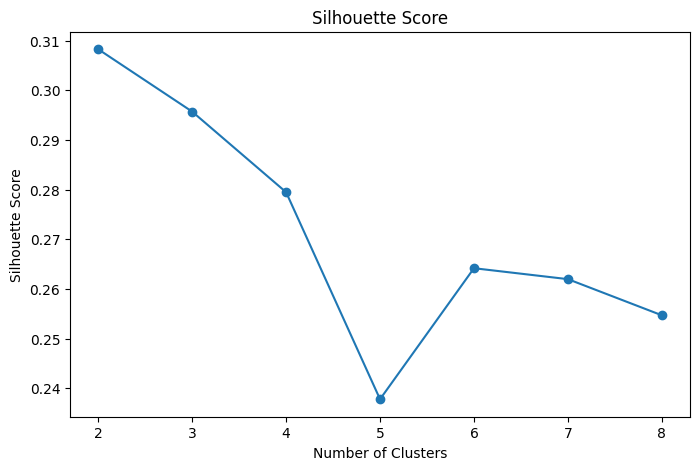

In [150]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

### Silhouette Score Results

The highest Silhouette Score is at k=2 (0.309), however k=2
provides only two groups which is not meaningful for real
market analysis.

k=3 has the second highest score (0.295) and provides
more meaningful and interpretable apartment groups.

### Decision: k=3

Based on both methods:
- Elbow Method → noticeable bend around k=3
- Silhouette Score → second highest at k=3 (0.295)
- Practical interpretation → 3 meaningful market segments

Therefore, we selected k=3 as the optimal number of clusters.


## Cluster Interpretation

After applying K-Means with k=3, three apartment groups were discovered:

- **Cluster 0:** Affordable small apartments with low price per m² (~$17)

- **Cluster 1:** High-rent compact apartments located in expensive cities such as Los Angeles and San Francisco, with the highest price per m² (~$33)

- **Cluster 2:** Large family apartments with more bedrooms and reasonable price per m² (~$14)

In [151]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

data.loc[X.index, "cluster"] = cluster_labels

data["cluster"].value_counts()

,count
cluster,
0.0,5416
2.0,2837
1.0,1682


### Cluster Distribution

- Cluster 0: 5,416 apartments (54%) → largest group
- Cluster 2: 2,837 apartments (29%) → medium group
- Cluster 1: 1,682 apartments (17%) → smallest group

The unequal distribution is expected and reflects
the real market — most apartments are affordable and small,
while luxury and large apartments are less common.

In [152]:
cluster_summary = data.groupby("cluster")[
    ["price", "square_meters", "bedrooms", "bathrooms", "price_per_m2"]
].mean().round(2)

cluster_summary

,price,square_meters,bedrooms,bathrooms,price_per_m2
cluster,,,,,
0.0,1092.08,66.57,1.31,1.02,17.26
1.0,2067.51,68.26,1.43,1.20,32.62
2.0,1834.18,137.53,2.75,2.16,13.72


## Cluster Interpretation

After applying K-Means with k=3, we analyzed the average values
of each cluster to understand what each group represents.

- **Cluster 0:** Affordable small apartments (17/m²),
  mostly found in Texas. Lowest price with small size (67m²)
  and ~1 bedroom.

- **Cluster 1:** High-rent compact apartments (33/m²),
  mostly located in California (Los Angeles, San Francisco, Seattle).
  Highest price (2,067) despite small size (68m²), indicating
  that location drives the price more than size.

- **Cluster 2:** Large family apartments (14/m²),
  mostly found in Texas. Largest size (138m²) with most bedrooms
  (2.75) and lowest price per m², suitable for families
  looking for more space.

### Key Insight
Cluster 1 has the highest price but similar size to Cluster 0.
This is explained by location — most C1 apartments are in
expensive cities like Los Angeles and San Francisco.

The price per m² confirms this:

- C0: 17/m² (mid-range cities)

- C1: 33/m² (premium locations)

- C2: 14/m² (suburban areas)

In [153]:
data[data["cluster"] == 0.0][["cityname", "state"]].value_counts().head(10)

,,count
cityname,state,
Austin,TX,481
Houston,TX,163
Dallas,TX,157
San Antonio,TX,154
Chicago,IL,104
Kansas City,MO,85
Madison,WI,84
Omaha,NE,66
Denver,CO,62


In [154]:
data[data["cluster"] == 1.0][["cityname", "state"]].value_counts().head(10)

,,count
cityname,state,
Los Angeles,CA,146
San Francisco,CA,104
Portland,OR,98
Seattle,WA,79
Anchorage,AK,37
Kent,WA,35
San Diego,CA,34
Renton,WA,34
Long Beach,CA,33


In [155]:
data[data["cluster"] == 2.0][["cityname", "state"]].value_counts().head(10)

,,count
cityname,state,
Los Angeles,CA,146
San Francisco,CA,104
Portland,OR,98
Seattle,WA,79
Anchorage,AK,37
Kent,WA,35
San Diego,CA,34
Renton,WA,34
Long Beach,CA,33


In [156]:
data.groupby("cluster")["state"].agg(lambda x: x.value_counts().index[0])

,state
cluster,
0.0,TX
1.0,CA
2.0,TX


## PCA Visualization

PCA reduces the numerical features into two components.
This helps us visualize the apartment clusters in 2D.

In [157]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

data.loc[X.index, "pca1"] = X_pca[:, 0]
data.loc[X.index, "pca2"] = X_pca[:, 1]

pca.explained_variance_ratio_

array([0.40806891, 0.23649935])

## Dimensionality Reduction (PCA)

PCA reduces the 7 numerical features into 2 principal components,
allowing us to visualize the apartment clusters in 2D.

### Explained Variance
- PCA Component 1: 40.8% of variance
- PCA Component 2: 23.6% of variance
- Total: 64.4% of information preserved

This means we can visualize the clusters while retaining
almost two-thirds of the original data information,
which is sufficient for pattern visualization.

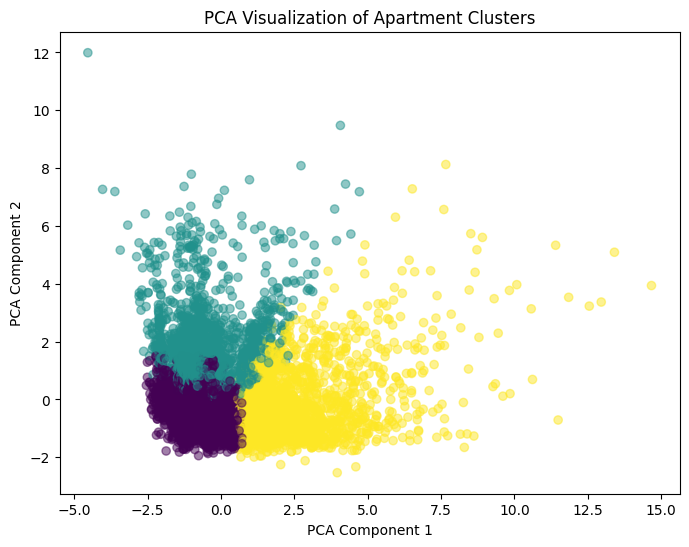

In [158]:
plt.figure(figsize=(8, 6))
plt.scatter(
    data.loc[X.index, "pca1"],
    data.loc[X.index, "pca2"],
    c=data.loc[X.index, "cluster"],
    alpha=0.5
)

plt.title("PCA Visualization of Apartment Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

### PCA Visualization of Apartment Clusters

The scatter plot shows the three apartment clusters in 2D space.
Each color represents one cluster:

- **Purple (Cluster 0):** Affordable small apartments,
  concentrated in the lower-left area indicating
  similar and consistent features.

- **Teal (Cluster 1):** High-rent compact apartments,
  spread upward indicating more variation in features,
  mostly driven by location differences across expensive cities.

- **Yellow (Cluster 2):** Large family apartments,
  spread to the right indicating larger size
  and more diverse price ranges.

The clusters are clearly separated, which confirms that
K-Means successfully identified distinct apartment groups.

## Anomaly Detection

We use Isolation Forest to detect unusual apartment listings.
Anomalies may represent apartments with unusual prices, sizes, or feature combinations.

In [159]:
iso = IsolationForest(contamination=0.03, random_state=42)

anomaly_labels = iso.fit_predict(X_scaled)

data.loc[X.index, "anomaly"] = anomaly_labels

data["anomaly"].value_counts()

,count
anomaly,
1.0,9636
-1.0,299


In [160]:
anomalies = data[data["anomaly"] == -1]

anomalies[
    ["price", "square_meters", "bedrooms", "bathrooms", "cityname", "state", "price_per_m2"]
].head(10)

,price,square_meters,bedrooms,bathrooms,cityname,state,price_per_m2
2,1390,9.940621,0.0,1.0,Arlington,VA,139.830298
3,925,10.776748,0.0,1.0,Seattle,WA,85.832943
5,2475,12.077390,0.0,1.0,Manhattan,NY,204.928383
8,1495,12.820614,0.0,1.0,San Francisco,CA,116.609080
14,1695,17.651570,0.0,1.0,San Francisco,CA,96.025453
38,1195,20.717369,0.0,1.0,Seattle,WA,57.681069
41,1250,21.181884,0.0,1.0,Seattle,WA,59.012692
46,1695,21.553496,0.0,1.0,San Francisco,CA,78.641535
49,1299,22.575429,0.0,1.0,Seattle,WA,57.540435
50,705,22.761235,1.0,1.0,Anchorage,AK,30.973715


### Anomaly Examples

The detected anomalies share common characteristics:
- Very small size (less than 25 m²) which is unusually small for an apartment
- Zero bedrooms combined with high price
- Very high price per m² (above 57/m²) compared to the market average (~20/m²)

These listings likely represent studio units,
storage spaces, or data entry errors in the original dataset.

## Association Rule Mining Preparation

> Add blockquote



Association Rule Mining works with categorical items.
So we convert numerical values into categories:

- price_category
- size_category

Then we combine them with:
- amenities
- pets_allowed
- has_photo

In [161]:
data["price"].describe()

,price
count,9935.000000
mean,1469.132360
std,850.644217
min,200.000000
25%,949.000000
50%,1271.000000
75%,1695.000000
max,9500.000000


### Step 1: Convert Numerical Features to Categories

Price boundaries are based on percentiles:
- low:        ≤ 949    (25th percentile)
- medium:     949 - 1,270  (50th percentile)
- high:       1,270 - 1,695 (75th percentile)
- very_high:  > 1,695

Size boundaries are based on percentiles:
- small:      ≤ 60 m²   (25th percentile)
- medium:     60 - 75 m²  (50th percentile)
- large:      75 - 102 m² (75th percentile)
- very_large: > 102 m²

In [162]:
rules_data = data[
    ["price", "square_meters", "pets_allowed", "has_photo", "amenities"]
].copy()

rules_data["price_category"] = pd.cut(
    rules_data["price"],
    bins=[0, 949, 1270, 1695, 100000],
    labels=["low", "medium", "high", "very_high"]
)

rules_data["size_category"] = pd.cut(
    rules_data["square_meters"],
    bins=[0, 60, 75, 102, 100000],
    labels=["small", "medium", "large", "very_large"]
)

print("Price categories:")
print(rules_data["price_category"].value_counts())
print("\nSize categories:")
print(rules_data["size_category"].value_counts())


Price categories:
price_category
high         2503
low          2486
medium       2480
very_high    2466
Name: count, dtype: int64

Size categories:
size_category
medium        2574
very_large    2548
small         2432
large         2381
Name: count, dtype: int64


### Category Distribution

The distribution across categories is balanced,
with approximately 25% of apartments in each category.
This confirms that our boundaries were correctly chosen
based on the actual data percentiles,
ensuring fair representation of all market segments.

In [163]:
rules_data["size_category"].value_counts()

,count
size_category,
medium,2574
very_large,2548
small,2432
large,2381


In [164]:
def split_amenities(x):
    if pd.isna(x) or x == "Unknown":
        return []

    return [
        item.strip().lower()
        for item in str(x).split(",")
        if item.strip()
    ]

### Step 2: Split Amenities

Each apartment has multiple amenities stored as a single text string.
We split them into individual items so each amenity can be
treated as a separate feature in the association rules.

Example:
- Before: "Parking,Pool,Gym,Dishwasher"
- After:  ["parking", "pool", "gym", "dishwasher"]

Apartments with no amenities or "Unknown" return an empty list.

## Transactions

Each apartment is converted into a list of items.
Example:
["price_medium", "size_small", "pets_cats,dogs", "amenity_parking"]

In [165]:
transactions = []

for _, row in rules_data.iterrows():
    items = []

    items.append("price_" + str(row["price_category"]))
    items.append("size_" + str(row["size_category"]))
    items.append("pets_" + str(row["pets_allowed"]).lower())
    items.append("photo_" + str(row["has_photo"]).lower())

    amenities_list = split_amenities(row["amenities"])
    items.extend(["amenity_" + a for a in amenities_list[:10]])

    transactions.append(items)

transactions[:3]

[['price_high', 'size_small', 'pets_unknown', 'photo_thumbnail'],
 ['price_low', 'size_small', 'pets_unknown', 'photo_thumbnail'],
 ['price_very_high',
  'size_small',
  'pets_unknown',
  'photo_thumbnail',
  'amenity_dishwasher',
  'amenity_elevator',
  'amenity_patio/deck',
  'amenity_pool',
  'amenity_storage']]

### Step 4: Apply Apriori Algorithm

We first convert the transactions into a binary matrix
where each column represents an item and each row represents
an apartment:
- True  → apartment has this feature
- False → apartment does not have this feature

Then we apply the Apriori algorithm with min_support=0.03,
meaning we only keep items that appear in at least 3% of apartments (~298 apartments).

Lower support = more rules but less reliable
Higher support = fewer rules but more reliable

In [166]:
te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(
    basket,
    min_support=0.03,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.066331,(amenity_ac)
1,0.031907,(amenity_basketball)
2,0.168395,(amenity_cable or satellite)
3,0.132562,(amenity_clubhouse)
4,0.328234,(amenity_dishwasher)


### Frequent Itemsets Results

The most common individual amenities found:
- dishwasher:        32.8% of apartments
- cable or satellite: 16.8% of apartments
- clubhouse:         13.3% of apartments
- ac:                 6.6% of apartments
- basketball:         3.2% of apartments

These single items will be combined to find
association rules between multiple features.

### Step 5: Generate Association Rules

We generate rules from the frequent itemsets with:
- metric = confidence
- min_threshold = 0.4 → rule must be correct at least 40% of the time

Results are sorted by lift to show the strongest relationships first.

In [167]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.4
)

rules = rules.sort_values(by="lift", ascending=False)

rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(10)

,antecedents,consequents,support,confidence,lift
24087,"(amenity_patio/deck, photo_thumbnail, amenity_...","(amenity_cable or satellite, pets_cats,dogs, a...",0.035632,0.581281,9.210566
24199,"(amenity_cable or satellite, pets_cats,dogs, a...","(amenity_patio/deck, photo_thumbnail, amenity_...",0.035632,0.564593,9.210566
24092,"(amenity_patio/deck, photo_thumbnail, amenity_...","(amenity_garbage disposal, pets_cats,dogs, ame...",0.035632,0.475168,9.202323
24197,"(amenity_garbage disposal, pets_cats,dogs, ame...","(amenity_patio/deck, photo_thumbnail, amenity_...",0.035632,0.690058,9.202323
24143,"(amenity_patio/deck, amenity_parking, amenity_...","(amenity_cable or satellite, pets_cats,dogs, p...",0.035632,0.566400,9.149893
24157,"(amenity_cable or satellite, pets_cats,dogs, p...","(amenity_patio/deck, amenity_parking, amenity_...",0.035632,0.575610,9.149893
19753,"(amenity_patio/deck, amenity_parking, amenity_...","(amenity_cable or satellite, pets_cats,dogs, a...",0.035833,0.569600,9.025480
19792,"(amenity_cable or satellite, pets_cats,dogs, a...","(amenity_patio/deck, amenity_parking, amenity_...",0.035833,0.567783,9.025480
24213,"(amenity_garbage disposal, amenity_cable or sa...","(amenity_patio/deck, pets_cats,dogs, photo_thu...",0.035632,0.460338,8.985185
24040,"(amenity_patio/deck, pets_cats,dogs, photo_thu...","(amenity_garbage disposal, amenity_cable or sa...",0.035632,0.695481,8.985185


### Association Rules Results

The top rules all have lift > 9.0, indicating very strong
and non-random relationships.

Key Finding:
Luxury amenities appear together as a package.
Apartments with patio/deck, internet, parking, and dishwasher
are very likely to also have:
- cable or satellite
- pets allowed (cats & dogs)
- garbage disposal

This means landlords bundle premium amenities together,
and finding one luxury feature strongly predicts others.

## Recommendation System

The system uses a Content-based approach, recommending apartments
based on similarity to user preferences.

The user provides:
- Budget (price)
- Preferred number of bedrooms
- Preferred number of bathrooms

A normalized similarity score is calculated for each apartment:

score = |price - budget| / budget
      + |bedrooms - preferred| / max_bedrooms
      + |bathrooms - preferred| / max_bathrooms

Each feature is normalized using the maximum value from the actual data
to ensure fair contribution. Lower score = better match.

The top apartments with the lowest scores are returned as recommendations.



In [168]:
def recommend_apartments(user_budget, user_bedrooms, user_bathrooms, top_n=10):
    temp = data.copy()

    temp = temp.dropna(subset=[
        "price",
        "bedrooms",
        "bathrooms",
        "square_meters",
        "cluster"
    ])

    max_bedrooms = max(temp["bedrooms"].max(), 1)
    max_bathrooms = max(temp["bathrooms"].max(), 1)

    temp["score"] = (
        abs(temp["price"] - user_budget) / user_budget +
        abs(temp["bedrooms"] - user_bedrooms) / max_bedrooms +
        abs(temp["bathrooms"] - user_bathrooms) / max_bathrooms
    )

    recommendations = temp.sort_values("score").head(top_n)

    return recommendations[
        [
            "price",
            "square_meters",
            "bedrooms",
            "bathrooms",
            "cityname",
            "state",
            "amenities",
            "cluster",
            "score"
        ]
    ]

In [176]:
recommend_apartments(
    user_budget=2500,
    user_bedrooms=2,
    user_bathrooms=1,
    top_n=10
)

,price,square_meters,bedrooms,bathrooms,cityname,state,amenities,cluster,score
2509,2500,60.386950,2.0,1.0,Hoboken,NJ,"Storage,Wood Floors",1.0,0.0000
4124,2500,69.677250,2.0,1.0,San Jose,CA,"Cable or Satellite,Clubhouse,Dishwasher,Hot Tu...",1.0,0.0000
1005,2501,46.544403,2.0,1.0,Boston,MA,"Cable or Satellite,Clubhouse,Dishwasher,Firepl...",1.0,0.0004
4645,2497,72.835952,2.0,1.0,Pasadena,CA,"Hot Tub,Parking,Patio/Deck,Pool",1.0,0.0012
6203,2495,85.935275,2.0,1.0,Los Angeles,CA,Parking,1.0,0.0020
6204,2495,85.935275,2.0,1.0,Los Angeles,CA,Parking,1.0,0.0020
383,2495,36.975394,2.0,1.0,San Francisco,CA,"Dishwasher,Refrigerator",1.0,0.0020
5919,2510,83.612700,2.0,1.0,Garfield,NJ,"Dishwasher,Refrigerator,Washer Dryer",0.0,0.0040
5201,2475,76.644975,2.0,1.0,Redondo Beach,CA,Storage,1.0,0.0100
7332,2470,100.242337,2.0,1.0,Lynnwood,WA,"Gym,Pool",1.0,0.0120


## Save Final Dataset

We save the cleaned dataset with clusters, PCA values, anomaly labels, and engineered features.
This file can later be used in the Streamlit interface.

In [170]:
data.to_csv("clean_housing_data.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


In [171]:
from google.colab import files
files.download("clean_housing_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>